# Démodulation en bande de base

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

import matplotlib as mpl
mpl.rcParams['axes.grid'] = True
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.size'] = 16

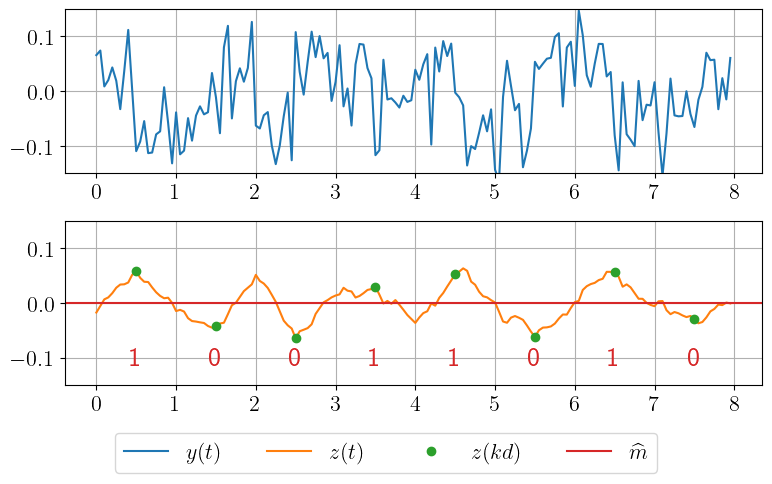

In [15]:
# Message
msg = np.array([1, 0, 0, 1, 1, 0, 1, 0])
M = len(msg)

# Temps & instants d'échantillonnage
Fe = 20
n = np.arange(0, M, 1/Fe)
idx = np.arange(M)*Fe + Fe//2

# Forme d'onde
# h = np.ones(Fe)
h = np.concatenate( ( np.ones(Fe//2), -np.ones(Fe//2) ) )/Fe

# Signal émis
x = np.kron(2*msg-1, h)

# Signal reçu (bruité)
b = np.random.normal(0, .05, x.shape)
y = x + b
z = np.correlate(y, h, mode="same")

####################

# Affichage

ylim = [-0.15, 0.15]
fig, axs = plt.subplots(2, 1, figsize=(8,5))

## Signal reçu
axs[0].plot(n,y, "C0", label="$y(t)$")
# for i in range(M):
#     axs[0].text(n[idx[i]], -.1, msg[i], ha="center", va="center", color="w", size=26, fontweight='bold')
#     axs[0].text(n[idx[i]], -.1, msg[i], ha="center", va="center", color="k", size=20)
axs[0].set_ylim(ylim)

## Échantilllonnage + seuillage
axs[1].plot(n, z, color="C1", label="$z(t)$")
for i in range(M):
    if i==0:
        axs[1].plot(n[idx[i]], z[idx[i]], "C2o", label="$z(kd)$")
    else:
        axs[1].plot(n[idx[i]], z[idx[i]], "C2o")
    axs[1].text(n[idx[i]], -.1, msg[i], ha="center", va="center", color="C3", size=20)
axs[1].axhline(0, color="C3", label="$\\widehat{m}$")
axs[1].set_ylim(ylim)

# Légende
fig.legend(loc="lower center", ncol=4)
fig.tight_layout()
fig.subplots_adjust(bottom=0.2)

# Enregistrement et affichage
plt.savefig("demodulation-bb-signaux.svg", bbox_inches="tight")
plt.show()